### Agent-Lab: ReACT RAG Agent

Objective of this notebook is evaluating and adapting the implementation of [ReAct Agent](https://langchain-ai.github.io/langgraph/how-tos/create-react-agent/) with retrieval evaluation.

---

In [1]:
%%capture
import json
import os
import nest_asyncio
from dotenv import load_dotenv
from IPython.display import Markdown, display
from notebooks import experiment_utils
from agent_lab.interface.api.messages.schema import MessageRequest

os.chdir("..")
load_dotenv()
nest_asyncio.apply()

# start dependency injection container
container = experiment_utils.bootstrap_container([__name__])

---
### XAI ReACT RAG Agent

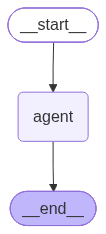

In [3]:
# Create Workflow

xai_agent = experiment_utils.create_xai_agent(
    agent_type="react_rag", llm_tag="grok-code-fast", api_key=os.getenv("XAI_API_KEY")
)
xai_agent_config = {
    "configurable": {
        "thread_id": xai_agent["id"],
    },
    "recursion_limit": 30,
}
xai_react_rag_agent = container.agent_registry().get_agent("react_rag")
xai_workflow = xai_react_rag_agent.get_workflow(xai_agent["id"],schema="public")

experiment_utils.print_graph(xai_workflow)

In [4]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="What is the pinnacle of excellence?",
    agent_id=xai_agent["id"],
)

inputs = xai_react_rag_agent.get_input_params(message, schema="public")
result = xai_workflow.invoke(inputs, xai_agent_config)
ai_message_content, workflow_state = xai_react_rag_agent.format_response(result)

In [5]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

<thinking>
Step 1: Analyze the question and user intent. The query "What is the pinnacle of excellence?" is broad and philosophical, seeking a profound definition of the highest form of achievement or success. Given the provided context from Sun Tzu's Art of War, the intent appears to be exploring excellence in strategy, leadership, or conflict resolution, where direct confrontation is not the ideal. The user likely wants an insightful, non-trivial answer rather than a generic one like "perfection" or "winning at all costs."

Step 2: Think about the solution. Draw from the context's core ideas without referencing it: supreme excellence involves winning by preventing battle altogether—through foresight, secrecy, baulking plans, and achieving outcomes without resistance or bloodshed. This contrasts with ordinary success (fighting and conquering). Generalize it to life/strategy: the pinnacle is not brute force but intelligent, invisible mastery that preserves resources and harmony. No external tools needed; context provides the foundation. Solution: Craft a concise, elegant response emphasizing anticipation, subtlety, and bloodless victory.

Step 3: Resolve with available elements. Formulate an original answer that embodies the context's philosophy (e.g., "breaking the enemy’s resistance without fighting," "plan secretly," "win without shedding a drop of blood") while making it standalone and accessible. Ensure it feels profound and complete.

Step 4: Verify against user intent. This addresses the query by providing a thoughtful, context-informed definition of excellence as strategic non-engagement, which aligns with the text's emphasis on true generalship. It avoids direct quotes or mentions of sources, stays neutral, and offers value without overcomplicating. If the query were purely abstract, this still fits as an elevated response; no criminal, explicit, or guideline-violating elements present.
</thinking>

<response>
The pinnacle of excellence is achieving complete victory by neutralizing opposition before it arises—through foresight, subtle strategy, and the art of rendering conflict unnecessary. It lies not in the glory of battle or the acclaim of conquest, but in the quiet mastery that preserves strength, avoids waste, and secures outcomes without a single drop of resistance or regret.
</response>

In [6]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="Kun je mijn vorige vraag en jouw antwoord herhalen in Nederlands alstublieft? Gebruik maximaal tien zinnen.",
    agent_id=xai_agent["id"],
)

inputs = xai_react_rag_agent.get_input_params(message, schema="public")
result = xai_workflow.invoke(inputs, xai_agent_config)
ai_message_content, workflow_state = xai_react_rag_agent.format_response(result)

In [7]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

<thinking>
Step 1: Analyse and understand the question and user intent.
The user asks to repeat the previous question ("What is the pinnacle of excellence?") and the previous answer, but now in Dutch, and limited to a maximum of ten sentences in total. The intent is a simple, direct translation and repetition of the prior exchange without adding new content or explanations.

Step 2: Think about the solution.
Translate the original English question and answer accurately into natural Dutch. The newly supplied context (additional excerpts from Sun Tzu's Art of War) is irrelevant to this request and must be ignored. Structure the entire response as a sequence of no more than ten sentences (ideally far fewer) that clearly states the prior question followed by the translated answer.

Step 3: Resolve the task with the tools at your disposal.
Create a concise Dutch text: one sentence for the previous question, then four short sentences that convey the full meaning of the previous answer. This keeps the total at five sentences, well under the limit. No tools beyond translation and formatting are needed.

Step 4: Verify if the solution address the user intent properly.
The resulting response directly repeats the requested content in Dutch, uses only five sentences, remains faithful to the original meaning, and contains nothing extra. It fully meets the query while adhering to the maximum-sentence constraint.
</thinking>

<response>
De vorige vraag was: Wat is het hoogtepunt van excellentie? 
Het hoogtepunt van excellentie is het behalen van een volledige overwinning door tegenstand te neutraliseren voordat die ontstaat. 
Dit gebeurt door vooruitziendheid, subtiele strategie en de kunst om conflict onnodig te maken. 
Het ligt niet in de glorie van de strijd of de lof van de verovering. 
Het is het stille meesterschap dat kracht behoudt, verspilling vermijdt en resultaten verzekert zonder een druppel weerstand of spijt.
</response>

---
### Anthropic ReACT RAG Agent

In [8]:
# Create Workflow

anthropic_agent = experiment_utils.create_anthropic_agent(
    agent_type="react_rag", llm_tag="claude-sonnet-5", api_key=os.getenv("ANTHROPIC_API_KEY")
)
anthropic_agent_config = {
    "configurable": {
        "thread_id": anthropic_agent["id"],
    },
    "recursion_limit": 30,
}
anthropic_react_rag_agent = container.agent_registry().get_agent("react_rag")
anthropic_workflow = anthropic_react_rag_agent.get_workflow(anthropic_agent["id"],schema="public")

In [9]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="What is the pinnacle of excellence?",
    agent_id=anthropic_agent["id"],
)

inputs = anthropic_react_rag_agent.get_input_params(message, schema="public")
result = anthropic_workflow.invoke(inputs, anthropic_agent_config)
ai_message_content, workflow_state = anthropic_react_rag_agent.format_response(result)

In [10]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

<thinking>
The query asks about "the pinnacle of excellence," and the context provided is clearly drawn from Sun Tzu's "The Art of War" (with Lionel Giles' translation and commentary). The context gives specific passages addressing what constitutes true excellence in military strategy—specifically that winning without fighting, through foiling the enemy's plans and achieving victory via strategy rather than brute force or visible combat, is the highest form of excellence.

Key points from context:
1. "To fight and conquer in all your battles is not supreme excellence; supreme excellence consists in breaking the enemy's resistance without fighting."
2. "The highest form of generalship is to baulk the enemy's plans"
3. "Neither is it the acme of excellence if you fight and conquer and the whole Empire says, 'Well done!'" - because true excellence is invisible, achieved through secret planning that foils enemies without obvious bloodshed.
4. "To see victory only when it is within the ken of the common herd is not the acme of excellence" - meaning true excellence isn't about achieving visible victories that everyone can recognize, but rather subtle strategic mastery that the ordinary person can't perceive.

So the answer should synthesize this: according to Sun Tzu's philosophy, the pinnacle of excellence is not winning through fighting and visible combat, but achieving victory through superior strategy, foiling the enemy's plans before they can act, and winning without ever needing to engage in battle. This represents the highest form of strategic mastery - something so subtle that common observers can't appreciate it, only true experts can recognize the skill involved.

I should give a thoughtful, well-rounded answer that captures this essence, since the query is somewhat open-ended/philosophical and the context strongly points to this specific interpretation from Sun Tzu's Art of War.
</thinking>

<response>
According to Sun Tzu's *The Art of War*, the pinnacle of excellence is not found in winning battles through combat, but in achieving victory without ever needing to fight at all. As Sun Tzu states: "To fight and conquer in all your battles is not supreme excellence; supreme excellence consists in breaking the enemy's resistance without fighting."

This idea unfolds in several layers:

1. **Strategic foresight over brute force** – "The highest form of generalship is to baulk the enemy's plans." True mastery lies in anticipating and neutralizing an opponent's intentions before conflict ever becomes necessary.

2. **Invisible mastery, not public glory** – Sun Tzu adds a subtle but profound point: "Neither is it the acme of excellence if you fight and conquer and the whole Empire says, 'Well done!'" Real excellence doesn't seek visible applause or recognition. As the commentator Tu Mu explains, it is "to plan secretly, to move surreptitiously, to foil the enemy's intentions and balk his schemes, so that at last the day may be won without shedding a drop of blood." The truest victories are often invisible to the untrained eye—what "the world's coarse thumb and finger fail to plumb."

3. **Beyond common perception** – "To see victory only when it is within the ken of the common herd is not the acme of excellence." True excellence operates on a level that ordinary observers cannot even recognize as mastery—because the battle was already won before it began, through foresight, positioning, and strategy rather than obvious heroics.

In essence, the pinnacle of excellence—whether in strategy, leadership, or life—is not dramatic triumph after a hard-fought struggle, but the quiet, almost imperceptible mastery of preventing conflict or difficulty altogether through wisdom, preparation, and foresight. It is the art of succeeding so completely and subtly that the victory appears effortless, even though it required the deepest skill to achieve.
</response>

In [11]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="Kun je mijn vorige vraag en jouw antwoord herhalen in Nederlands alstublieft? Gebruik maximaal tien zinnen.",
    agent_id=anthropic_agent["id"],
)

inputs = anthropic_react_rag_agent.get_input_params(message, schema="public")
result = anthropic_workflow.invoke(inputs, anthropic_agent_config)
ai_message_content, workflow_state = anthropic_react_rag_agent.format_response(result)

In [12]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

[{'signature': 'EssECtMCCBIYAipAbYLjKlhUARbkAUKcoq+Y9iFxaFj1vPfT77m34JDXNv6M4uY5ghfwyjOOttFw6Crc6Y1AwdwbnyGnhCeSDz5CfTIPY2xhdWRlLXNvbm5ldC01OABCCHRoaW5raW5nWiQ3NWYxMmRjZi1kOWVkLTQyZGItODRjYS0wNmFlMmZhOGVmZTCaAREKD2NsYXVkZS1zb25uZXQtNagBgp6d1gbCAUkICRAAGhsB18AC2ooDTzcFAhIEJq0FZowDTzcFr/kEJq0gAjIEEnHPJToEKipxdEIEODMjikoEODMjilAAWgTZBeFWYARoAXAB2gFgChZwcmVmaXhfYmVmb3JlX2Jsb2NrX3YxEiCirSUN8DB1IM3M9QEcsiWzwm7Sn/z5Syx9LTpLlQ+UaSIAMiDCwBPIapyS4i+Wbz2GF3aPi3pEyQKtzAl7+h4JivtOH0gDEgxY2AVFo1aWgD7z8FMaDNg+2KTQCQz9KrzN7yIwgMcINesbjWaCwHtAZhHAdh9FcoFvYlSQK3xqedMh1O0151UrngNkjEHqhz15/1BDKqQBhNUZXQe209W+/o+qlHxBHn2ed8NoxnsHM4rwRY3cJ8xLpspS/Zpra1AXMFTR+/XM0NRm/TnuU2guaGTbSzkKm2KAl+0QWPOgfphXe7xpYl3WkLzx4DHXHDOe9WzLLHA5Uz/TYAMucgJ55nSOjIsrQIgpsqVN/mXwX5eTYNQ2zw/xOwIU4cRZwrPHuLCTPvUx5C4rAXmv4UsG8U6TvhNKGpOzDokYAQ==', 'thinking': '', 'type': 'thinking'}, {'text': '<thinking>\nDe gebruiker vraagt om een herhaling van de vorige vraag en mijn antwoord, maar dan in het Nederlands en in maximaal tien zinnen. Ik moet dus zowel de oorspronkelijke vraag ("Wat is het toppunt van voortreffelijkheid?") als een beknopte samenvatting van mijn antwoord vertalen en samenvatten. De context die nu is meegegeven gaat over andere onderwerpen uit Sun Tzu (spionage, terrein, directe/indirecte aanval), maar is niet direct relevant voor deze vertaalopdracht - ik moet me dus baseren op mijn vorige antwoord uit het gesprek zelf. Ik zal de kernboodschap kort en bondig weergeven binnen de gestelde limiet van tien zinnen.\n</thinking>\n\n<response>\nUw vorige vraag was: "Wat is het toppunt van voortreffelijkheid?" Mijn antwoord was gebaseerd op Sun Tzu\'s *De Kunst van het Oorlogsvoeren*. Daarin wordt gesteld dat ware voortreffelijkheid niet ligt in het winnen van gevechten door strijd, maar in het overwinnen van de vijand zonder ooit te hoeven vechten. De hoogste vorm van leiderschap is het doorkruisen van de plannen van de tegenstander voordat een conflict zelfs maar ontstaat. Sun Tzu zegt bovendien dat echte meesterschap niet gezocht wordt in openbare lof of zichtbare triomfen. De grootste overwinningen zijn vaak onzichtbaar en worden niet begrepen door gewone waarnemers. Zoals de commentator Tu Mu het uitlegt: men moet "in het geheim plannen, onopvallend bewegen" om zo de strijd te winnen zonder bloedvergieten. Kortom, het toppunt van voortreffelijkheid is de stille, haast onzichtbare meesterschap waarbij wijsheid en vooruitziendheid conflict volledig voorkomen.\n</response>', 'type': 'text'}]

---
### Local ReACT RAG Agent

In [13]:
# Create Workflow

local_agent = experiment_utils.create_local_agent(
    agent_type="react_rag", llm_tag=os.getenv("SIMULATION_LLM_MODEL"),
    local_endpoint=os.getenv("SIMULATION_LLM_API_BASE"),
)
local_agent_config = {
    "configurable": {
        "thread_id": local_agent["id"],
    },
    "recursion_limit": 30,
}
local_react_rag_agent = container.agent_registry().get_agent("react_rag")
local_workflow = local_react_rag_agent.get_workflow(local_agent["id"], schema="public")

In [14]:
print(f"Model: {os.getenv('SIMULATION_LLM_MODEL')}")

Model: gpt-oss:20b


In [15]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="What is the pinnacle of excellence?",
    agent_id=local_agent["id"],
)

inputs = local_react_rag_agent.get_input_params(message, schema="public")
result = local_workflow.invoke(inputs, local_agent_config)
ai_message_content, workflow_state = local_react_rag_agent.format_response(result)

In [16]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

<thinking>
The user asks for a concise answer to “What is the pinnacle of excellence?” The supplied context is a collection of excerpts about military strategy, especially from Sun Tzu and related thinkers, emphasizing that true excellence lies in winning without fighting—through deception, secrecy, and strategy that neutralizes the enemy’s plans before they can act. The answer should capture that idea without referencing the specific text. It should be clear, reflective, and possibly mention key virtues like wisdom, benevolence, and unity of spirit as components of excellence. It should not mention the source or that we used context.
</thinking>
<response>
The pinnacle of excellence is the art of securing victory before conflict begins—using wisdom, strategy, and secrecy so that the enemy’s plans are undone and resistance disappears without a single blow. It is the mastery of foresight, deception, and unity of purpose that turns potential war into a pre‑empted peace. In other words, supreme triumph is achieved when one defeats an adversary’s will to fight, so that no blood is shed and true success rests in the preservation of life. 
</response>

In [17]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="Kun je mijn vorige vraag en jouw antwoord herhalen in Nederlands alstublieft? Gebruik maximaal tien zinnen.",
    agent_id=local_agent["id"],
)

inputs = local_react_rag_agent.get_input_params(message, schema="public")
result = local_workflow.invoke(inputs, local_agent_config)
ai_message_content, workflow_state = local_react_rag_agent.format_response(result)

In [18]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

<response>
Wat is de top van uitmuntendheid?  
De hoogste vorm van uitmuntendheid is het veiligstellen van een overwinning voordat de strijd begint, door inzicht, strategie en geheimhouding.  
Het draait om het neutraliseren van het wanhopige winnende plan van de vijand, zodat geen enkel bloed gedruizt.  
Dit vereist wijsheid, vernuft, mededogen en eenheid van doel en geest.  
Hierdoor ontstaat een pre‑combatituïse vrede die werkelijk succes weerspiegelt.  
Met andere woorden, de grootste triomf is het overwinnen van de wil om te strijden, zonder geweld.  
</response>

---
### OpenAI ReACT RAG Agent

In [19]:
# Create Workflow

openai_agent = experiment_utils.create_openai_agent(
    agent_type="react_rag", llm_tag="gpt-5-nano", api_key=os.getenv("OPENAI_API_KEY")
)
openai_agent_config = {
    "configurable": {
        "thread_id": openai_agent["id"],
    },
    "recursion_limit": 30,
}
openai_react_rag_agent = container.agent_registry().get_agent("react_rag")
openai_workflow = openai_react_rag_agent.get_workflow(openai_agent["id"],schema="public")

In [20]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="What is the pinnacle of excellence?",
    agent_id=openai_agent["id"],
)

inputs = openai_react_rag_agent.get_input_params(message, schema="public")
result = openai_workflow.invoke(inputs, openai_agent_config)
ai_message_content, workflow_state = openai_react_rag_agent.format_response(result)

In [21]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

<thinking>Provide a concise summary: the pinnacle of excellence in strategic thought is to win without fighting—subduing the enemy’s resistance and thwarting their plans through superior strategy, deception, and diplomacy, aiming for peace with minimal or no bloodshed.</thinking>
<response>The pinnacle of excellence is to win without fighting: to break the enemy’s resistance without a battle and to foil their plans without direct confrontation. It emphasizes achieving victory with minimal bloodshed and laying the groundwork for lasting peace through superior strategy, diplomacy, and unity. In practice, this means outmaneuvering opponents, disrupting their schemes, and resolving conflict with the least cost to all involved. </response>

In [22]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="Kun je mijn vorige vraag en jouw antwoord herhalen in Nederlands alstublieft? Gebruik maximaal tien zinnen.",
    agent_id=openai_agent["id"],
)

inputs = openai_react_rag_agent.get_input_params(message, schema="public")
result = openai_workflow.invoke(inputs, openai_agent_config)
ai_message_content, workflow_state = openai_react_rag_agent.format_response(result)

In [23]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

<thinking>Om de vraag te beantwoorden, geef ik een compacte Nederlandse weergave van de vorige vraag en mijn eerder gegeven antwoord, binnen tien zinnen.</thinking>
<response>Mijn vorige vraag was: "Wat is het toppunt van uitmuntendheid?" Jouw antwoord luidde: "Het toppunt van uitmuntendheid is winnen zonder te vechten: de weerstand van de vijand doorbreken zonder slag, en hun plannen zonder directe confrontatie te dwarsbomen." Het benadrukt overwinning met zo min mogelijk bloedvergieten en het leggen van de basis voor blijvende vrede door superieure strategie, diplomatie en eenheid. In de praktijk betekent het de tegenstander uit te manoeuvreren, hun plannen te verstoren en conflicten op te lossen tegen de kleinste kosten voor alle betrokkenen.</response>